In [6]:
import numpy as np
import json

# load the two matrices to compare 

#k1_file='K_matrix_GD.json'
k1_file='EL_noise2.0_run1/K_matrix_D2.json'
k2_file='EL_noise2.0_run2/K_matrix_D2.json'

with open(k1_file, 'r') as file:
        k_data = json.load(file)
        K1 = np.array(k_data['K'])

with open(k2_file, 'r') as file:
        k_data = json.load(file)
        K2 = np.array(k_data['K'])


K1_clipped = np.clip(K1, 1.0, 10000.)
K2_clipped = np.clip(K2, 1.0, 10000.)


#print("K1=",K1)
#print("K2=",K2)
print("K1.shape=",K1.shape)
print("K2.shape=",K2.shape)

K1.shape= (15, 15)
K2.shape= (15, 15)


Best permutation: [ 0  1  2  3  4  5  8  6  7 11 10  9 12 13 14]
Min distance: 1605.9840768293416


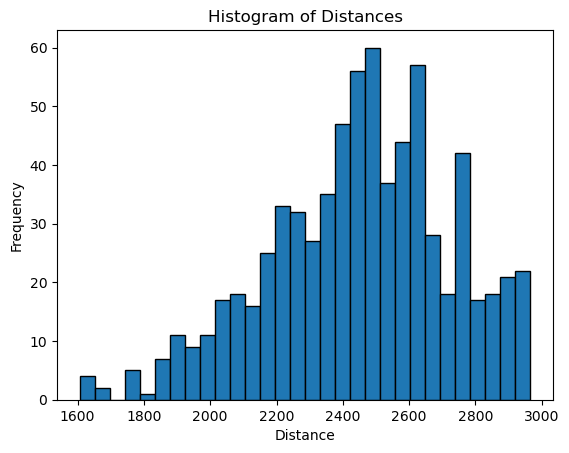

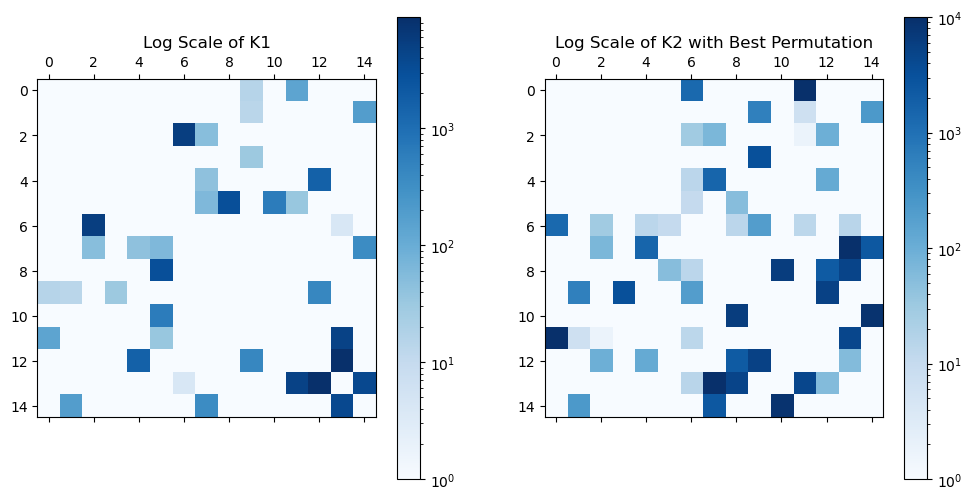

In [7]:

import itertools

min_distance = None
best_permutation = None
list_distances = np.array([])
v = [0, 1, 2, 3, 4, 5]
for permutation in list(itertools.permutations(v)):
    permutation_vector = np.array(permutation)
    list_perm = np.concatenate(([0, 1, 2, 3, 4, 5], permutation_vector + 6, [12, 13, 14]))
    #distance = np.sum((K1_clipped - K2_clipped[list_perm,:][:,list_perm])**2)
    #distance = np.sum((K1-K2[list_perm,:][:,list_perm])**2)
    distance = np.sum(np.log(K1_clipped/K2_clipped[list_perm,:][:,list_perm])**2)
    list_distances = np.append(list_distances, distance)
    if min_distance is None or distance < min_distance:
        min_distance = distance
        best_permutation = list_perm
print("Best permutation:", best_permutation)
print("Min distance:", min_distance)

K2_permuted = K2_clipped[best_permutation,:][:,best_permutation]    




import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Plotting the histogram
plt.hist(list_distances, bins=30, edgecolor='black')
plt.title('Histogram of Distances')
plt.xlabel('Distance')
plt.ylabel('Frequency')
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot K1
cax1 = axes[0].matshow(K1_clipped, cmap='Blues', norm=LogNorm())
axes[0].set_title('Log Scale of K1')
fig.colorbar(cax1, ax=axes[0])

# Plot K2 with best permutation
cax2 = axes[1].matshow(K2_permuted, cmap='Blues', norm=LogNorm())
axes[1].set_title('Log Scale of K2 with Best Permutation')
fig.colorbar(cax2, ax=axes[1])

plt.show()


    #print("K2[list_perm, list_perm]=",K2[list_perm, list_perm])

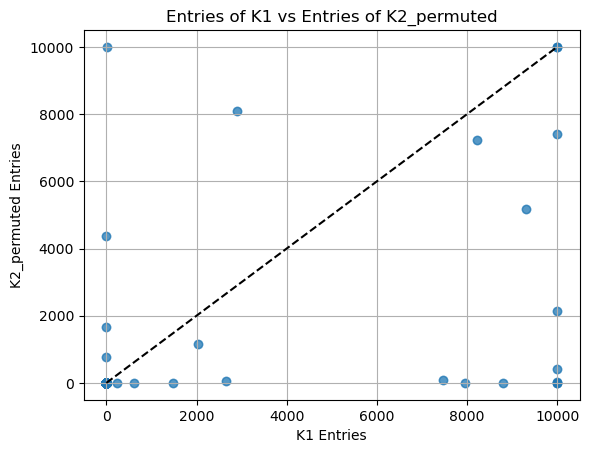

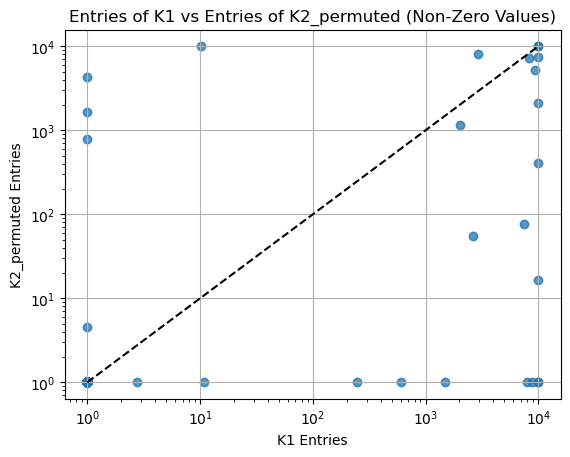

In [3]:
import matplotlib.pyplot as plt

# Flatten K1 and K2_permuted
K1_flat = K1_clipped.flatten()
K2_permuted_flat = K2_permuted.flatten()


plt.scatter(K1_flat, K2_permuted_flat, alpha=0.5)
plt.title('Entries of K1 vs Entries of K2_permuted')
plt.xlabel('K1 Entries')
plt.ylabel('K2_permuted Entries')
plt.grid(True)
plt.plot([0.0, 10000.0], [0.0, 10000.0], color='black', linestyle='--')
# Set axis range equal
#plt.axis('equal')
plt.show()



# Exclude values equal to 0 from K1_flat and K2_permuted_flat
non_zero_indices = (K1_flat > 0) & (K2_permuted_flat > 0)
K1_non_zero = K1_flat[non_zero_indices]
K2_permuted_non_zero = K2_permuted_flat[non_zero_indices]

# Plot the entries of K1 vs K2_permuted
plt.scatter(K1_non_zero, K2_permuted_non_zero, alpha=0.5)
plt.title('Entries of K1 vs Entries of K2_permuted (Non-Zero Values)')
plt.xlabel('K1 Entries')
plt.ylabel('K2_permuted Entries')
plt.xscale('log')
plt.yscale('log')
plt.grid(True)

# Set axis range equal
#plt.axis('equal')

# Add y=x line
min_val = min(K1_non_zero.min(), K2_permuted_non_zero.min())
max_val = max(K1_non_zero.max(), K2_permuted_non_zero.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--')

plt.show()